In [2]:
# وارد کردن کتابخانه‌ها
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    make_scorer,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

# خواندن داده 
df = pd.read_csv("bank-full.csv", sep=";")

print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
# جدا کردن متغیر هدف از ویژگی‌ها
TARGET = "y"

X = df.drop(columns=[TARGET])
y = df[TARGET]

# duration را حذف می‌کنیم چون در سناریوی پیش‌بینی قبل از تماس،
# در زمان تصمیم‌گیری در دسترس نیست.
X = X.drop(columns=["duration"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (45211, 15)
y shape: (45211,)


In [4]:
# تقسیم داده به Train، Validation و Test
# نسبت نهایی: 70% Train، 15% Validation، 15% Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (31647, 15)
Validation: (6782, 15)
Test: (6782, 15)


In [5]:
# شناسایی ستون‌های عددی و categorical
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


C:\Users\hp\AppData\Local\Temp\ipykernel_14060\3007901307.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [6]:
# پیش‌پردازش ستون‌های عددی
numeric_pipeline = Pipeline(
    steps=[
        # اگر مقدار missing وجود داشت، median استفاده می‌شود.
        ("imputer", SimpleImputer(strategy="median")),

        # استانداردسازی برای مدل‌هایی مثل Logistic Regression
        ("scaler", StandardScaler())
    ]
)

# پیش‌پردازش ستون‌های categorical
categorical_pipeline = Pipeline(
    steps=[
        # پر کردن missing values
        ("imputer", SimpleImputer(strategy="most_frequent")),

        # تبدیل categorical به عدد
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# ترکیب دو نوع preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [7]:
# مدل Logistic Regression
logistic_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]
)

# مدل Decision Tree
tree_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=8,
            random_state=RANDOM_STATE
        ))
    ]
)

# مدل Random Forest
forest_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

In [8]:
def evaluate_model(model, X_data, y_data):
    """
    Calc. of Key Metrics
    """

    # پیش‌بینی کلاس
    y_pred = model.predict(X_data)

    # احتمال کلاس مثبت
    y_proba = model.predict_proba(X_data)[:, 1]

    results = {
        "Accuracy": accuracy_score(y_data, y_pred),
        "Precision": precision_score(
            y_data, y_pred, pos_label="yes", zero_division=0
        ),
        "Recall": recall_score(
            y_data, y_pred, pos_label="yes", zero_division=0
        ),
        "F1": f1_score(
            y_data, y_pred, pos_label="yes", zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            (y_data == "yes").astype(int),
            y_proba
        )
    }

    return results

In [9]:
# آموزش هر سه مدل فقط روی Train

logistic_model.fit(X_train, y_train)

tree_model.fit(X_train, y_train)

forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [10]:
# ارزیابی هر سه مدل روی Validation

results = []

for model_name, model in [
    ("Logistic Regression", logistic_model),
    ("Decision Tree", tree_model),
    ("Random Forest", forest_model)
]:
    metrics = evaluate_model(model, X_val, y_val)
    metrics["Model"] = model_name
    results.append(metrics)

comparison = pd.DataFrame(results)

comparison = comparison[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.893099,0.657534,0.181360,0.284304,0.769888
1,Decision Tree,0.896048,0.678715,0.212846,0.324065,0.715145
2,Random Forest,0.896343,0.645367,0.254408,0.364950,0.792979


In [11]:
# مدل پایه Random Forest برای tuning

rf_for_tuning = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

In [12]:
# محدوده‌ای که برای hyperparameterها بررسی می‌کنیم

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12],
    "model__min_samples_leaf": [1, 2]
}

param_grid

{'model__n_estimators': [100, 200],
 'model__max_depth': [8, 12],
 'model__min_samples_leaf': [1, 2]}

In [13]:
# ساخت scorer مخصوص F1
# چون کلاس مثبت در این پروژه "yes" است،
# باید این موضوع را به GridSearchCV اعلام کنیم.

f1_yes_scorer = make_scorer(
    f1_score,
    pos_label="yes"
)

# مدل Random Forest برای tuning
rf_for_tuning = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

# محدوده hyperparameterها
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 12],
    "model__min_samples_leaf": [1, 2]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    scoring=f1_yes_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# فقط Train در tuning استفاده می‌شود
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [8, 12], 'model__min_samples_leaf': [1, 2], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...pos_label=yes)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exam

In [14]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Best CV F1:
0.27369854364823465


In [15]:
# بهترین مدل پیدا شده توسط GridSearchCV
tuned_model = grid_search.best_estimator_

# ارزیابی روی Validation
tuned_results = evaluate_model(
    tuned_model,
    X_val,
    y_val
)

tuned_results

{'Accuracy': 0.8963432615747567,
 'Precision': 0.7136150234741784,
 'Recall': 0.19143576826196473,
 'F1': 0.3018867924528302,
 'ROC-AUC': 0.7999280466895167}

In [16]:
# مقایسه Random Forest قبل و بعد از tuning

before_tuning = comparison[
    comparison["Model"] == "Random Forest"
].iloc[0].to_dict()

after_tuning = tuned_results.copy()

before_after = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Before Tuning": [
        before_tuning["Accuracy"],
        before_tuning["Precision"],
        before_tuning["Recall"],
        before_tuning["F1"],
        before_tuning["ROC-AUC"]
    ],
    "After Tuning": [
        after_tuning["Accuracy"],
        after_tuning["Precision"],
        after_tuning["Recall"],
        after_tuning["F1"],
        after_tuning["ROC-AUC"]
    ]
})

before_after

,Metric,Before Tuning,After Tuning
0,Accuracy,0.896343,0.896343
1,Precision,0.645367,0.713615
2,Recall,0.254408,0.191436
3,F1,0.364950,0.301887
4,ROC-AUC,0.792979,0.799928


In [17]:
# پیش‌بینی روی Validation
y_val_pred = tuned_model.predict(X_val)

# ساخت confusion matrix
cm = confusion_matrix(
    y_val,
    y_val_pred,
    labels=["no", "yes"]
)

print(cm)

[[5927   61]
 [ 642  152]]


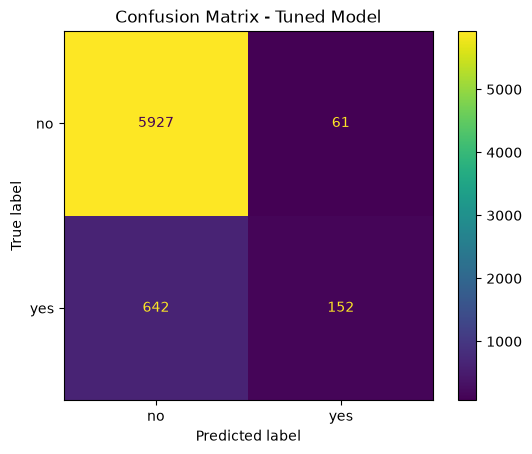

In [18]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["no", "yes"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned Model")
plt.show()

In [19]:
# ساخت DataFrame برای بررسی خطاها

error_df = X_val.copy()

error_df["actual"] = y_val.values
error_df["predicted"] = y_val_pred

# احتمال پیش‌بینی کلاس yes
error_df["probability_yes"] = tuned_model.predict_proba(X_val)[:, 1]

# مشخص کردن نوع خطا
error_df["error_type"] = "Correct"

error_df.loc[
    (error_df["actual"] == "no") &
    (error_df["predicted"] == "yes"),
    "error_type"
] = "False Positive"

error_df.loc[
    (error_df["actual"] == "yes") &
    (error_df["predicted"] == "no"),
    "error_type"
] = "False Negative"

error_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,actual,predicted,probability_yes,error_type
26011,50,management,married,tertiary,no,-470,yes,no,cellular,19,nov,2,160,1,failure,no,no,0.055675,Correct
39191,43,services,single,secondary,no,-63,yes,no,cellular,18,may,3,374,1,other,no,no,0.184490,Correct
33449,37,blue-collar,single,secondary,no,2235,yes,no,cellular,20,apr,2,151,2,failure,no,no,0.066668,Correct
24496,56,management,married,tertiary,no,935,yes,no,cellular,17,nov,1,-1,0,unknown,no,no,0.076687,Correct
8264,34,management,married,secondary,no,1105,yes,yes,unknown,2,jun,4,-1,0,unknown,no,no,0.041372,Correct


In [20]:
# تعداد ارورها
error_counts = error_df["error_type"].value_counts()

error_counts

error_type
Correct           6079
False Negative     642
False Positive      61
Name: count, dtype: int64

In [21]:
# سه خطای واقعی مدل را نمایش می‌دهیم

three_errors = error_df[
    error_df["error_type"].isin(
        ["False Positive", "False Negative"]
    )
].head(3)

three_errors

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,actual,predicted,probability_yes,error_type
3840,24,blue-collar,married,primary,no,656,yes,no,unknown,16,may,1,-1,0,unknown,yes,no,0.034608,False Negative
27177,31,management,married,tertiary,no,4148,yes,no,cellular,21,nov,3,99,9,other,yes,no,0.145849,False Negative
40690,46,management,married,tertiary,no,4693,no,yes,cellular,7,aug,1,394,2,failure,yes,no,0.442660,False Negative


In [22]:
# ویژگی‌های مهم را برای سه خطا مشاهده می‌کنیم

columns_to_show = [
    "age",
    "job",
    "marital",
    "education",
    "balance",
    "housing",
    "loan",
    "contact",
    "campaign",
    "pdays",
    "previous",
    "poutcome",
    "actual",
    "predicted",
    "probability_yes",
    "error_type"
]

three_errors[columns_to_show]

,age,job,marital,education,balance,housing,loan,contact,campaign,pdays,previous,poutcome,actual,predicted,probability_yes,error_type
3840,24,blue-collar,married,primary,656,yes,no,unknown,1,-1,0,unknown,yes,no,0.034608,False Negative
27177,31,management,married,tertiary,4148,yes,no,cellular,3,99,9,other,yes,no,0.145849,False Negative
40690,46,management,married,tertiary,4693,no,yes,cellular,1,394,2,failure,yes,no,0.442660,False Negative


In [23]:
# محاسبه نرخ خطا برای گروه‌های مختلف شغلی

error_df["is_error"] = (
    error_df["actual"] != error_df["predicted"]
)

job_error = (
    error_df
    .groupby("job")["is_error"]
    .mean()
    .sort_values(ascending=False)
)

job_error

job
student          0.188976
retired          0.187311
unemployed       0.139896
self-employed    0.121094
technician       0.110116
admin.           0.109961
management       0.108931
housemaid        0.091954
services         0.086495
blue-collar      0.074048
entrepreneur     0.046948
unknown          0.046512
Name: is_error, dtype: float64

In [24]:
# نرخ خطا بر اساس education

education_error = (
    error_df
    .groupby("education")["is_error"]
    .mean()
    .sort_values(ascending=False)
)

education_error

education
unknown      0.136201
tertiary     0.121569
secondary    0.097540
primary      0.078594
Name: is_error, dtype: float64

In [25]:
# نرخ خطا بر اساس housing

housing_error = (
    error_df
    .groupby("housing")["is_error"]
    .mean()
    .sort_values(ascending=False)
)

housing_error

housing
no     0.140242
yes    0.073597
Name: is_error, dtype: float64

In [26]:
# محاسبه Permutation Importance
# scorer باید بداند که کلاس مثبت "yes" است.

f1_yes_scorer = make_scorer(
    f1_score,
    pos_label="yes"
)

perm_result = permutation_importance(
    tuned_model,
    X_val,
    y_val,
    scoring=f1_yes_scorer,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [27]:
feature_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

feature_importance = feature_importance.sort_values(
    "importance_mean",
    ascending=False
)

feature_importance

,feature,importance_mean,importance_std
14,poutcome,0.237099,0.007401
12,pdays,0.088178,0.004378
13,previous,0.035420,0.003758
10,month,0.027034,0.006637
6,housing,0.021049,0.004674
11,campaign,0.017119,0.005984
8,contact,0.016969,0.009754
9,day,0.010722,0.003019
1,job,0.008767,0.005629
3,education,0.007988,0.003885


In [28]:
# نمایش 10 ویژگی مهم‌تر

top_features = feature_importance.head(10)

top_features

,feature,importance_mean,importance_std
14,poutcome,0.237099,0.007401
12,pdays,0.088178,0.004378
13,previous,0.035420,0.003758
10,month,0.027034,0.006637
6,housing,0.021049,0.004674
11,campaign,0.017119,0.005984
8,contact,0.016969,0.009754
9,day,0.010722,0.003019
1,job,0.008767,0.005629
3,education,0.007988,0.003885


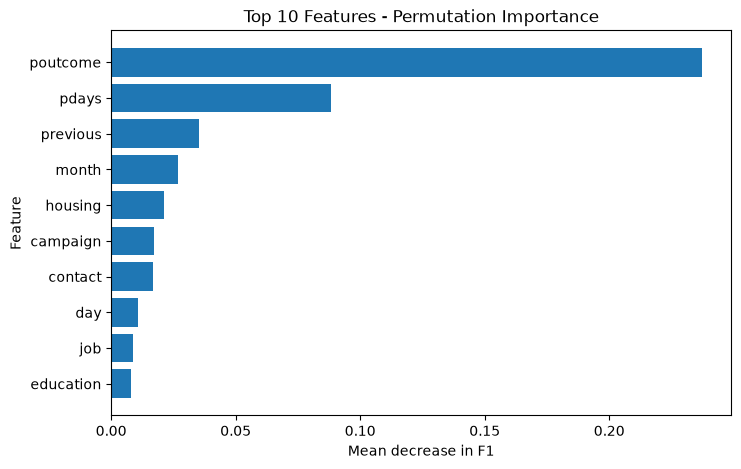

In [29]:
top_features_sorted = top_features.sort_values(
    "importance_mean"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features_sorted["feature"],
    top_features_sorted["importance_mean"]
)

plt.xlabel("Mean decrease in F1")
plt.ylabel("Feature")
plt.title("Top 10 Features - Permutation Importance")

plt.show()

In [30]:
# انتخاب مدل نهایی بر اساس عملکرد Validation
# Random Forest قبل از tuning بهترین F1 را بین مدل‌های بررسی‌شده داشت.

final_model = forest_model

print("Final model: Random Forest")

Final model: Random Forest


In [31]:
# ارزیابی نهایی فقط روی Test
# Test تا این مرحله در انتخاب مدل استفاده نشده است.

test_results = evaluate_model(
    final_model,
    X_test,
    y_test
)

test_results

{'Accuracy': 0.897670303745208,
 'Precision': 0.6655518394648829,
 'Recall': 0.2509457755359395,
 'F1': 0.36446886446886445,
 'ROC-AUC': 0.7801319021821637}

In [32]:
# ساخت جدول نهایی عملکرد مدل روی Test

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Test": [
        test_results["Accuracy"],
        test_results["Precision"],
        test_results["Recall"],
        test_results["F1"],
        test_results["ROC-AUC"]
    ]
})

final_results

,Metric,Test
0,Accuracy,0.897670
1,Precision,0.665552
2,Recall,0.250946
3,F1,0.364469
4,ROC-AUC,0.780132


[[5889  100]
 [ 594  199]]


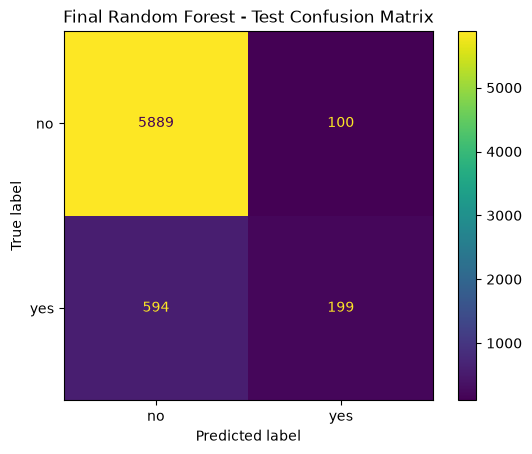

In [34]:
# پیش‌بینی روی Test
y_test_pred = final_model.predict(X_test)

# ساخت Confusion Matrix
cm_test = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["no", "yes"]
)

print(cm_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["no", "yes"]
)

disp.plot()

plt.title("Final Random Forest - Test Confusion Matrix")
plt.show()

In [35]:
# Error Analysis برای مدل نهایی

y_val_pred_final = final_model.predict(X_val)

error_df = X_val.copy()

error_df["actual"] = y_val.values
error_df["predicted"] = y_val_pred_final

error_df["probability_yes"] = (
    final_model.predict_proba(X_val)[:, 1]
)

error_df["error_type"] = "Correct"

error_df.loc[
    (error_df["actual"] == "no") &
    (error_df["predicted"] == "yes"),
    "error_type"
] = "False Positive"

error_df.loc[
    (error_df["actual"] == "yes") &
    (error_df["predicted"] == "no"),
    "error_type"
] = "False Negative"

error_df["is_error"] = (
    error_df["actual"] != error_df["predicted"]
)

error_df["error_type"].value_counts()

error_type
Correct           6079
False Negative     592
False Positive     111
Name: count, dtype: int64

In [ ]:
# پیش‌بینی
f1_yes_scorer = make_scorer(
    f1_score,
    pos_label="yes"
)

perm_result = permutation_importance(
    final_model,
    X_val,
    y_val,
    scoring=f1_yes_scorer,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [37]:
feature_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

feature_importance = feature_importance.sort_values(
    "importance_mean",
    ascending=False
)

feature_importance

,feature,importance_mean,importance_std
14,poutcome,0.185692,0.006667
10,month,0.088849,0.010159
12,pdays,0.068615,0.004284
8,contact,0.045822,0.009141
6,housing,0.037238,0.008231
13,previous,0.031989,0.001918
1,job,0.031247,0.005880
11,campaign,0.019978,0.006677
9,day,0.019689,0.001612
3,education,0.015690,0.007804


In [38]:
top_features = feature_importance.head(10)

top_features

,feature,importance_mean,importance_std
14,poutcome,0.185692,0.006667
10,month,0.088849,0.010159
12,pdays,0.068615,0.004284
8,contact,0.045822,0.009141
6,housing,0.037238,0.008231
13,previous,0.031989,0.001918
1,job,0.031247,0.005880
11,campaign,0.019978,0.006677
9,day,0.019689,0.001612
3,education,0.015690,0.007804
